In [2]:
import os
import pandas as pd
from matplotlib import pyplot as plt
from utilsforecast.plotting import plot_series
import yfinance as yf
import numpy as np
import warnings


warnings.filterwarnings('ignore')

In [14]:
# amd = yf.Ticker("AMD")
ticker = 'AMD'
num_years = 5
interval_days = 1
download_fresh = False
if not download_fresh and os.path.exists(f'../data/{ticker}_{num_years}y_daily.csv'):
    daily_data = pd.read_csv(f'../data/{ticker}_{num_years}y_daily.csv', index_col=0, header=[0,1])
else:
    # daily_data = yf.download(tickers=ticker, period=f'{num_years}y', interval=f'{interval_days}d')
    daily_data = yf.download(tickers=ticker, start='2020-12-05', end='2025-12-05', interval=f'{interval_days}d')

In [13]:
daily_data.to_csv(f'../data/{ticker}_{num_years}y_daily.csv', index=True)

In [11]:
daily_data[:2]

Price,Close,High,Low,Open,Volume
Ticker,AMD,AMD,AMD,AMD,AMD
Date,,,,,
2020-12-07,94.070000,95.000000,92.970001,94.949997,39815700
2020-12-08,92.919998,94.739998,91.900002,94.050003,33907500


In [15]:
try:
    daily_data.columns = daily_data.columns.droplevel(1)
except Exception as e:
    print(e)
    pass
print(daily_data.columns)
daily_data[['Close', 'High', 'Low', 'Open', 'Volume']] = daily_data[['Close', 'High', 'Low', 'Open', 'Volume']].astype(float)
daily_data.index = pd.to_datetime(daily_data.index)
daily_data[:2]

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Date')


Date,Close,High,Low,Open,Volume
2020-12-08,92.919998,94.739998,91.900002,94.050003,33907500.0
2020-12-09,89.830002,94.699997,89.160004,92.760002,52170400.0


In [8]:
from statsmodels.tsa.stattools import adfuller

# Extract the 'Close' column as a series
close_series = daily_data['log_return']

# Run ADF test
def check_stationarity(series):
    result = adfuller(series.dropna())  # Drop NaN values if any
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    if result[1] < 0.05:
        print("The series is stationary.")
    else:
        print("The series is not stationary.")

check_stationarity(close_series)

ADF Statistic: -36.183588883657805
p-value: 0.0
The series is stationary.


In [5]:
def compute_RSI(df, column="Close", window=14):
    # Price changes
    delta = df[column].diff()

    # Separate gains and losses
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)

    # Wilder's exponential moving average
    gain_ema = gain.ewm(alpha=1/window, adjust=False).mean()
    loss_ema = loss.ewm(alpha=1/window, adjust=False).mean()

    # Relative Strength
    rs = gain_ema / loss_ema

    # RSI
    rsi = 100 - (100 / (1 + rs))

    return rsi

In [6]:
def add_SMA_MACD(df, price_col="Close"):
    # SMA 10
    df["SMA10"] = df[price_col].rolling(window=10).mean()

    # MACD
    ema12 = df[price_col].ewm(span=12, adjust=False).mean()
    ema26 = df[price_col].ewm(span=26, adjust=False).mean()

    df["MACD"] = ema12 - ema26
    df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
    df["MACD_hist"] = df["MACD"] - df["MACD_signal"]

In [7]:
daily_data["RSI14"] = compute_RSI(daily_data, column="Close", window=14)
daily_data['pct_change'] = daily_data['Close'].pct_change()
daily_data['log_volume'] = daily_data['Volume'].apply(np.log)
daily_data['log_return'] = np.log1p(daily_data["pct_change"])
add_SMA_MACD(daily_data)

In [85]:
daily_data['day_of_week'] = daily_data.index.dayofweek
day_of_week_encoded = pd.get_dummies(daily_data['day_of_week'], prefix='dow')
daily_data = pd.concat([daily_data, day_of_week_encoded], axis=1)

In [72]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

In [86]:
features = ['log_return', 'log_volume', 'RSI14', 'MACD_hist', 'SMA10', 'MACD', 'MACD_signal', 'Low', 'High']
features += [col for col in daily_data.columns if col.startswith('dow_')]
target = 'Close'
daily_data = daily_data.dropna(axis=0)
X = daily_data[features].values
y = daily_data[target].values
seq_len = 10
batch_size = 8

In [87]:
# Example: standardize log returns
from sklearn.preprocessing import MinMaxScaler

scaler_x = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))
X = scaler_x.fit_transform(X)
y = scaler_y.fit_transform(y.reshape(-1, 1))


In [88]:
def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])
    return torch.tensor(X_seq, dtype=torch.float32), torch.tensor(y_seq, dtype=torch.float32)

X_seq, y_seq = create_sequences(X, y, seq_len)

# Split train/test
train_horizon = 0.7
train_size = int(len(X_seq) * 0.8)
train_end = train_size
train_start = train_end - int(train_horizon * train_end)
X_train, X_test = X_seq[train_start:train_size], X_seq[train_size:]
y_train, y_test = y_seq[train_start:train_size], y_seq[train_size:]
initial_price = daily_data.iloc[train_end+seq_len-1]['Close']

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)


In [89]:
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=50, dropout=0.2):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                             num_layers=1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(input_size=hidden_size, hidden_size=hidden_size,
                             num_layers=1, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_size, 25)
        self.act1 = nn.ReLU()
        self.fc2 = nn.Linear(25, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        out, _ = self.lstm2(out)
        out = self.dropout2(out)
        out = out[:, -1, :]
        out = self.fc1(out)
        out = self.act1(out)
        out = self.fc2(out)
        return out


In [303]:
def train_loop(model, criterion, optimizer, num_epochs=10):
    # input_size = len(features)
    # model = LSTMRegressor(input_size)
    # criterion = nn.MSELoss()
    # optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in tqdm(range(num_epochs)):
        model.train()
        mean_train_loss = 0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            mean_train_loss += loss.item()
            loss.backward()
            optimizer.step()
        mean_train_loss = mean_train_loss / len(train_loader)

        if (epoch+1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                val_pred = model(X_test)
                val_loss = criterion(val_pred, y_test)
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {mean_train_loss:.6f}, Val Loss: {val_loss.item():.6f}")


In [90]:
#base_model = train_loop()
from torch.optim.lr_scheduler import ReduceLROnPlateau
input_size = len(features)
base_model = LSTMRegressor(input_size)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(base_model.parameters(), lr=1e-3)
sched = ReduceLROnPlateau(optimizer, mode='min', patience=5)

In [274]:
optimizer = torch.optim.Adam(base_model.parameters(), lr=1e-4)
sched = ReduceLROnPlateau(optimizer, mode='min', patience=4)

In [316]:
train_loop(base_model, criterion, optimizer, num_epochs=10)

100%|██████████| 10/10 [00:02<00:00,  3.88it/s]

Epoch 10/10, Train Loss: 0.000584, Val Loss: 0.002697


In [310]:
torch.save(base_model.state_dict(), f'../models/{ticker}_{num_years}_LSTM.pt')

In [77]:
def predict_prices(model, X_test):
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test).numpy()
    return y_pred

In [78]:
def reconstruct_prices(log_returns, initial_price):
    log_cum_sum = np.cumsum(log_returns, axis=0)
    norm_prices = np.exp(log_cum_sum)
    prices = initial_price * norm_prices
    return prices


In [91]:
base_model = LSTMRegressor(input_size)
base_model.load_state_dict(torch.load(f'../models/{ticker}_{num_years}_LSTM.pt'))

<All keys matched successfully>

(247, 1)


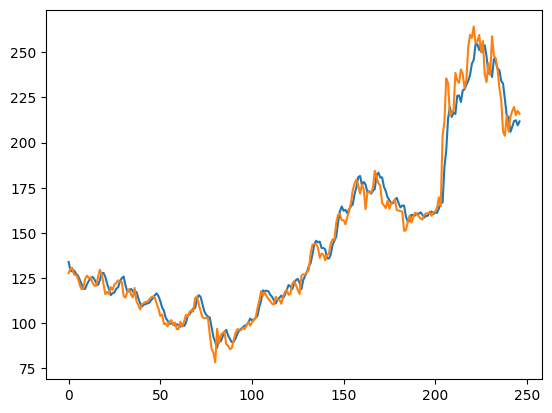

In [92]:
prices_pred = predict_prices(base_model, X_test)
print(prices_pred.shape)
prices_pred = scaler_y.inverse_transform(prices_pred)
prices_true = scaler_y.inverse_transform(y_test)
plt.plot(prices_pred, label='Predicted')
plt.plot(prices_true, label='True')

(248, 1)


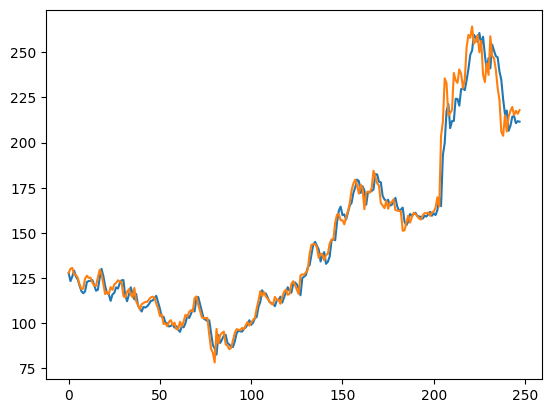

In [313]:
prices_pred = predict_prices(base_model, X_test)
print(prices_pred.shape)
prices_pred = scaler_y.inverse_transform(prices_pred)
prices_true = scaler_y.inverse_transform(y_test)
plt.plot(prices_pred, label='Predicted')
plt.plot(prices_true, label='True')

In [314]:
from sklearn.metrics import mean_squared_error
print(np.sqrt(mean_squared_error(y_true=prices_true[:250], y_pred=prices_pred[:250])))

7.181606435540528


In [233]:
y_naive_pred = np.roll(prices_true, -1)
y_naive_pred[0] = y_naive_pred[2]
print(np.sqrt(mean_squared_error(y_true=prices_true[:200], y_pred=y_naive_pred[:200])))

3.830588960338615


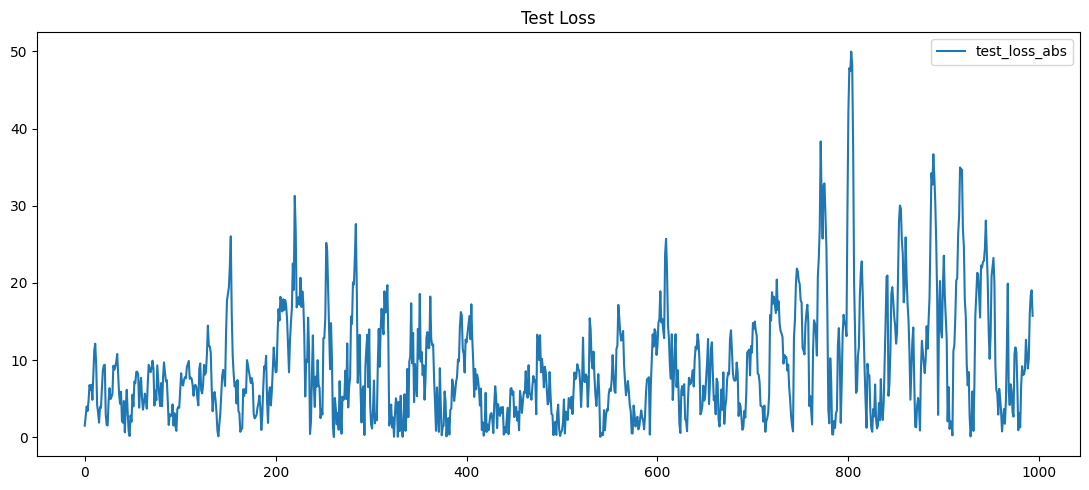

In [24]:
def plot_test_loss(y_true: np.ndarray, y_pred:np.ndarray) -> None:
    _, ax = plt.subplots(nrows=1, ncols=1, figsize=(11, 5))
    ax.set_title('Test Loss')
    ax.plot(np.abs(y_true-y_pred), label='test_loss_abs')
    ax.legend()
    plt.tight_layout()
plot_test_loss(df_train['Close'].values[2:], prices_pred_train)

In [295]:
pred_diff = np.ediff1d(prices_pred)
true_diff = np.ediff1d(prices_true)
dir_pred = (pred_diff < 0).astype(int)
dir_true = (true_diff < 0).astype(int)
print(dir_pred[:5])
print(dir_true[:5])
print(np.unique(dir_pred, return_counts=True))
print(np.unique(dir_true, return_counts=True))
from sklearn.metrics import accuracy_score
print(accuracy_score(dir_true, dir_pred))

[1 0 0 1 1]
[0 0 1 1 1]
(array([0, 1]), array([129, 118]))
(array([0, 1]), array([130, 117]))
0.5101214574898786


In [9]:
def split_train_test(df: pd.DataFrame, train_size:float=0.8, train_horizon:float = 1.0) -> tuple[pd.DataFrame, pd.DataFrame]:
    N = len(df)
    train_end = int(N * train_size)
    train_start = train_end - int(train_horizon * train_end)
    train_len = train_end - train_start
    # test_len = N - train_len
    df_train = df[train_start:train_end]
    df_test = df[train_end:]
    return df_train, df_test

In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
features = ['log_volume', 'RSI14', 'MACD_hist', 'SMA10', 'MACD', 'MACD_signal']
daily_data[features] =  daily_data[features].shift(1)
daily_data = daily_data.dropna(axis=0)
target = 'log_return'

In [45]:
df_train, df_test = split_train_test(daily_data, train_size=0.8)
model = SARIMAX(endog=df_train[target].values, exog=df_train[features].values, order=(10, 2, 10))
res = model.fit(disp=False)

D:\PythonProjects\TimeSeries\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [30]:
def plot_preds(y_true, y_pred) -> None:
    _, ax = plt.subplots(nrows=1, ncols=1, figsize=(11, 5))
    ax.plot(y_true, label='Actual')
    ax.plot(y_pred, label='Predicted')
    ax.legend()

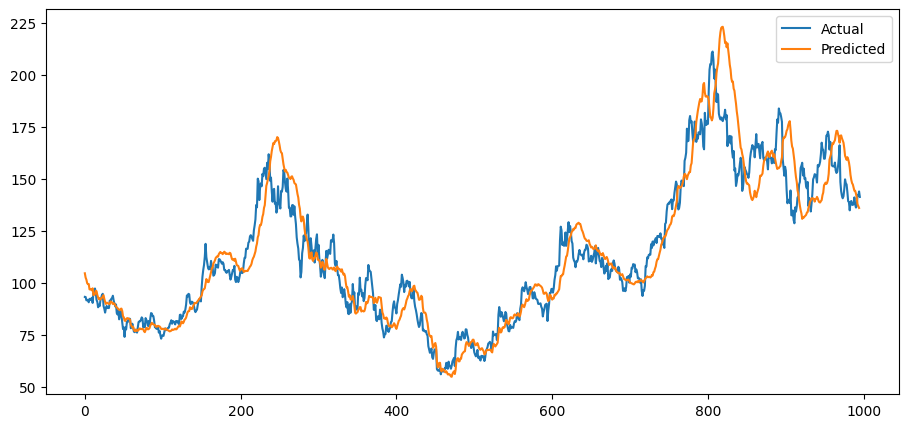

In [51]:
# y_pred = res.get_prediction(start=0, end=len(df_train)-1, dynamic=False)
y_pred_train = res.predict(start=1, end=len(df_train)-1)
#y_pred_train = df_train[target].values[1:]
price_1 = float(df_train.iloc[0]['Close'])
prices_pred_train = [price_1 * np.exp(y_pred_train[0])]
for r in y_pred_train[1:]:
    prices_pred_train.append(prices_pred_train[-1] * np.exp(r))
# plot_preds(df_train['log_return'].values, y_pred_train)
plot_preds(df_train['Close'].values, prices_pred_train)

996 249
[ 0.11492716 -0.02010017 -0.00994142 -0.01654712 -0.00463804]
[ 0.0001148   0.00043961  0.002256    0.00583472 -0.00657025]
147.48149072911502


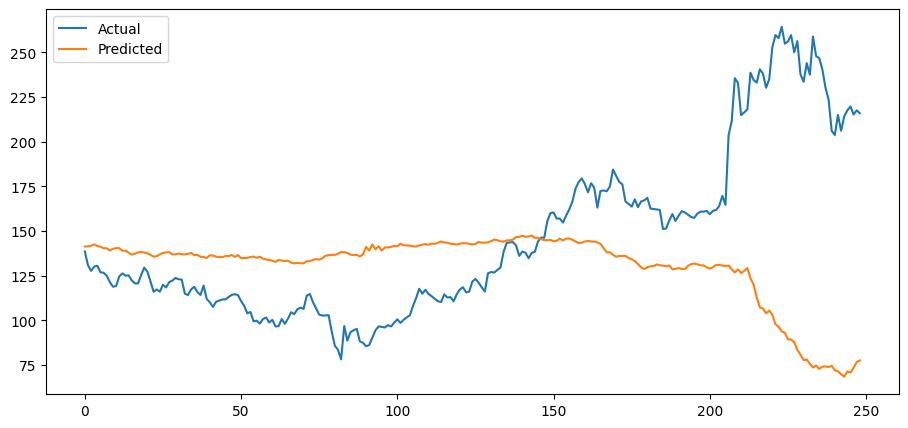

In [71]:
print(len(df_train), len(df_test))
df_train, df_test = split_train_test(daily_data, train_size=0.8)
# df_train[features] = df_train[features].shift(-1).dropna(axis=0)
# df_test[features] = df_test[features].shift(-1).dropna(axis=0)
y_pred_test = multinomial_train_and_predict(df_train, df_test, features+[target]) #res.forecast(steps=len(df_test), exog=df_test[features].values)
print(y_pred_train[:5])
print(y_pred_test[:5])
price_last = float(df_train.iloc[-1]['Close'])
prices_pred_test = [price_last * np.exp(y_pred_test[0])]
for r in y_pred_test[1:]:
    prices_pred_test.append(prices_pred_test[-1] * np.exp(r))
print(np.max(np.abs(prices_pred_test)))

# print(len(prices_pred_test))
plot_preds(df_test['Close'].values, prices_pred_test)
# plot_preds(df_test['Close'].values, prices_pred_test)

In [65]:
def multinomial_train_and_predict(df_train: pd.DataFrame, df_test: pd.DataFrame, features:list[str], p:int=10) -> np.ndarray:
    train_len = len(df_train)
    test_len = len(df_test)
    X_train = []
    y_train = []

    for t in range(p, train_len):
        lagged = []
        for lag in range(1, p + 1):
            lagged.extend(df_train.iloc[t - lag][features].values)
        X_train.append(lagged)
        y_train.append(df_train.iloc[t]["log_return"])

    X_train = np.array(X_train)
    y_train = np.array(y_train)

    coef = np.linalg.lstsq(X_train, y_train, rcond=None)[0]

    X_test = []
    history = pd.concat([df_train.tail(p), df_test], axis=0)
    history = history.reset_index(drop=True)

    for t in range(p, p + test_len):
        lagged = []
        for lag in range(1, p + 1):
            lagged.extend(history.iloc[t - lag][features].values)
        X_test.append(lagged)

    X_test = np.array(X_test)

    y_pred = X_test @ coef
    return y_pred
